# Notebook 01: Data Preparation and Exploratory Analysis

This notebook covers the initial data preparation steps for our Market Risk VaR analysis:

1. **Portfolio Configuration** - Load and display portfolio parameters
2. **Data Download** - Fetch historical price data from Yahoo Finance
3. **Return Calculations** - Compute log returns for assets and portfolio
4. **Exploratory Analysis** - Statistical summary and visualizations
5. **Train/Test Split** - Define estimation and backtesting periods

---

## 1.1 Import Libraries and Load Configuration

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# Data source
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
from IPython.display import display, Markdown
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load configuration
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

# Extract parameters
TICKERS = config['portfolio']['tickers']
WEIGHTS = np.array(config['portfolio']['weights'])
NAMES = config['portfolio']['names']

START_DATE = config['dates']['start']
END_DATE = config['dates']['end']
TRAIN_START = config['dates']['train_start']
TRAIN_END = config['dates']['train_end']
TEST_START = config['dates']['test_start']
TEST_END = config['dates']['test_end']

CONFIDENCE_VAR = config['var_params']['confidence_var']
CONFIDENCE_ES = config['var_params']['confidence_es']
SIMULATIONS = config['var_params']['simulations']
WINDOW = config['var_params']['rolling_window']

print("Configuration loaded successfully!")

Configuration loaded successfully!


## 1.2 Portfolio Composition

Our portfolio consists of five major technology stocks, weighted to reflect a concentrated tech-sector exposure typical of growth-oriented investment strategies.

In [3]:
# Display portfolio composition
portfolio_df = pd.DataFrame({
    'Ticker': TICKERS,
    'Company': NAMES,
    'Weight': WEIGHTS,
    'Weight (%)': [f"{w*100:.0f}%" for w in WEIGHTS]
})

display(Markdown("### Portfolio Composition"))
display(portfolio_df)

### Portfolio Composition

,Ticker,Company,Weight,Weight (%)
0,AAPL,Apple Inc.,0.3000,30%
1,MSFT,Microsoft Corp.,0.2500,25%
2,NVDA,NVIDIA Corp.,0.2000,20%
3,GOOG,Alphabet Inc.,0.1500,15%
4,AMD,AMD Inc.,0.1000,10%


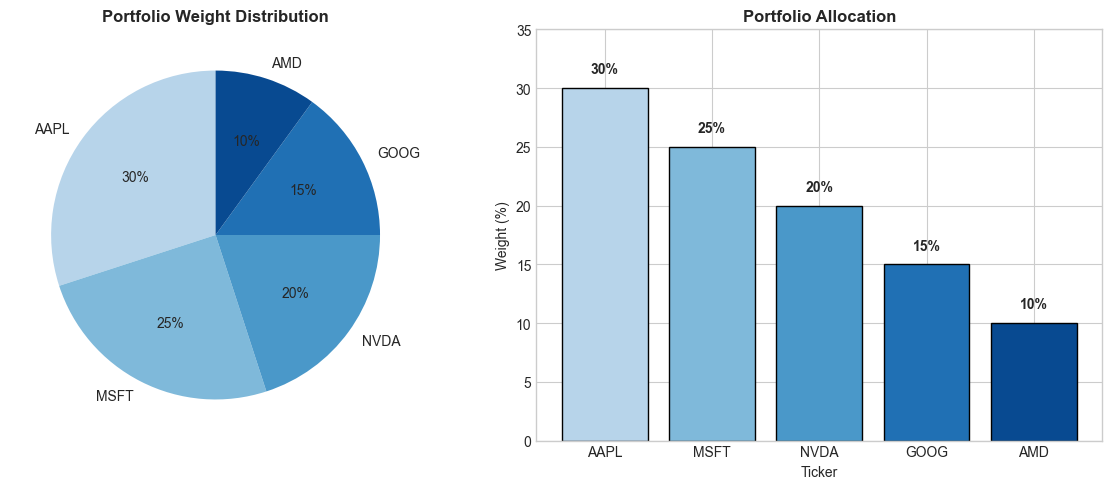

In [4]:
# Portfolio weight visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(TICKERS)))
axes[0].pie(WEIGHTS, labels=TICKERS, autopct='%1.0f%%', colors=colors, startangle=90)
axes[0].set_title('Portfolio Weight Distribution', fontsize=12, fontweight='bold')

# Bar chart
bars = axes[1].bar(TICKERS, WEIGHTS * 100, color=colors, edgecolor='black')
axes[1].set_ylabel('Weight (%)')
axes[1].set_xlabel('Ticker')
axes[1].set_title('Portfolio Allocation', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 35)

# Add value labels on bars
for bar, weight in zip(bars, WEIGHTS):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{weight*100:.0f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/01_portfolio_composition.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Download Historical Price Data

We retrieve adjusted close prices from Yahoo Finance for the analysis period (January 2022 - December 2025).

In [5]:
def get_price_data(tickers, start_date, end_date):
    """
    Download adjusted close prices from Yahoo Finance.
    
    Parameters:
    -----------
    tickers : list
        List of stock ticker symbols
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with dates as index and tickers as columns
    """
    data = yf.download(tickers, start=start_date, end=end_date, 
                       auto_adjust=True, progress=False)
    
    # Handle yfinance column structure (MultiIndex or single level)
    if isinstance(data.columns, pd.MultiIndex):
        # New yfinance format: MultiIndex with ('Price', 'Ticker')
        prices = data['Close']
    else:
        # Single ticker or old format
        if 'Close' in data.columns:
            prices = data['Close']
        elif 'Adj Close' in data.columns:
            prices = data['Adj Close']
        else:
            prices = data
    
    # Ensure tickers are in correct order
    if isinstance(prices, pd.DataFrame) and len(tickers) > 1:
        prices = prices[tickers]
    
    return prices

# Download price data
print(f"Downloading data from {START_DATE} to {END_DATE}...")
prices_df = get_price_data(TICKERS, START_DATE, END_DATE)
print(f"Downloaded {len(prices_df)} trading days of data.")

Downloaded 983 trading days of data.


In [6]:
# Display price data sample
display(Markdown("### Price Data (First 5 rows)"))
display(prices_df.head())

display(Markdown("### Price Data (Last 5 rows)"))
display(prices_df.tail())

### Price Data (First 5 rows)

Ticker,AAPL,MSFT,NVDA,GOOG,AMD
Date,,,,,
2022-01-03,178.2703,323.8984,30.0644,144.0885,150.2400
2022-01-04,176.0078,318.3445,29.2350,143.4350,144.4200
2022-01-05,171.3260,306.1239,27.5522,136.7179,136.1500
2022-01-06,168.4660,303.7050,28.1251,136.6161,136.2300
2022-01-07,168.6325,303.8598,27.1958,136.0733,132.0000


### Price Data (Last 5 rows)

Ticker,AAPL,MSFT,NVDA,GOOG,AMD
Date,,,,,
2025-11-25,276.9700,476.9900,177.8200,323.6400,206.1300
2025-11-26,277.5500,485.5000,180.2600,320.2800,214.2400
2025-11-28,278.8500,492.0100,177.0000,320.1200,217.5300
2025-12-01,283.1000,486.7400,179.9200,315.1200,219.7600
2025-12-02,286.1900,490.0000,181.4600,316.0200,215.2400


In [7]:
# Check for missing data
missing = prices_df.isnull().sum()
print("Missing values per ticker:")
print(missing)

# Forward fill any missing values
if missing.sum() > 0:
    prices_df = prices_df.ffill()
    print("\nMissing values filled using forward fill.")

Missing values per ticker:
Ticker
AAPL    0
MSFT    0
NVDA    0
GOOG    0
AMD     0
dtype: int64


## 1.4 Calculate Returns

We calculate **log returns** (continuously compounded returns) which are preferred for risk modeling because:
- They are time-additive (multi-period returns = sum of single-period returns)
- They are more likely to follow a normal distribution
- They are symmetric for gains and losses

In [8]:
def compute_log_returns(prices):
    """
    Compute log returns from price data.
    
    Parameters:
    -----------
    prices : pd.DataFrame or pd.Series
        Price data
        
    Returns:
    --------
    pd.DataFrame or pd.Series
        Log returns
    """
    return np.log(prices / prices.shift(1)).dropna()

def compute_portfolio_returns(asset_returns, weights, normalize=True):
    """
    Compute portfolio returns as weighted sum of asset returns.
    
    Parameters:
    -----------
    asset_returns : pd.DataFrame
        Returns for each asset
    weights : array-like
        Portfolio weights
    normalize : bool
        Whether to normalize weights to sum to 1
        
    Returns:
    --------
    pd.Series
        Portfolio returns
    """
    weights = np.array(weights)
    if normalize:
        weights = weights / weights.sum()
    return asset_returns.dot(weights)

In [9]:
# Calculate returns
returns_df = compute_log_returns(prices_df)
portfolio_returns = compute_portfolio_returns(returns_df, WEIGHTS)

print(f"Calculated returns for {len(returns_df)} trading days.")
display(Markdown("### Asset Returns (First 5 rows)"))
display(returns_df.head())

Calculated returns for 982 trading days.


### Asset Returns (First 5 rows)

Ticker,AAPL,MSFT,NVDA,GOOG,AMD
Date,,,,,
2022-01-04,-0.0128,-0.0173,-0.0280,-0.0045,-0.0395
2022-01-05,-0.0270,-0.0391,-0.0593,-0.0480,-0.0590
2022-01-06,-0.0168,-0.0079,0.0206,-0.0007,0.0006
2022-01-07,0.0010,0.0005,-0.0336,-0.0040,-0.0315
2022-01-10,0.0001,0.0007,0.0056,0.0114,0.0000


## 1.5 Summary Statistics

Key statistics for understanding the risk-return profile of each asset and the portfolio.

In [10]:
from scipy.stats import skew, kurtosis

def compute_summary_stats(returns):
    """
    Compute comprehensive summary statistics for returns.
    """
    stats = pd.DataFrame({
        'Mean (Daily)': returns.mean(),
        'Mean (Annual)': returns.mean() * 252,
        'Std (Daily)': returns.std(),
        'Std (Annual)': returns.std() * np.sqrt(252),
        'Min': returns.min(),
        'Max': returns.max(),
        'Skewness': returns.apply(skew),
        'Kurtosis': returns.apply(kurtosis)
    })
    return stats.T

# Asset statistics
asset_stats = compute_summary_stats(returns_df)

# Add portfolio statistics
asset_stats['Portfolio'] = [
    portfolio_returns.mean(),
    portfolio_returns.mean() * 252,
    portfolio_returns.std(),
    portfolio_returns.std() * np.sqrt(252),
    portfolio_returns.min(),
    portfolio_returns.max(),
    skew(portfolio_returns),
    kurtosis(portfolio_returns)
]

display(Markdown("### Summary Statistics"))
display(asset_stats.round(4))

### Summary Statistics

Ticker,AAPL,MSFT,NVDA,GOOG,AMD,Portfolio
Mean (Daily),0.0005,0.0004,0.0018,0.0008,0.0004,0.0008
Mean (Annual),0.1215,0.1062,0.4613,0.2015,0.0923,0.1947
Std (Daily),0.0181,0.0169,0.0339,0.0206,0.0343,0.0189
Std (Annual),0.2865,0.2688,0.5384,0.3272,0.5442,0.2999
Min,-0.0970,-0.0803,-0.1859,-0.1013,-0.1493,-0.0707
Max,0.1426,0.0965,0.2181,0.0950,0.2137,0.1367
Skewness,0.3109,0.1203,0.2358,-0.0931,0.3652,0.2429
Kurtosis,6.1288,3.0493,3.7600,3.0050,3.7927,3.8784


In [11]:
# Key observations
display(Markdown(f"""
### Key Observations

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Portfolio Daily Volatility | {portfolio_returns.std():.2%} | Average daily risk |
| Portfolio Annual Volatility | {portfolio_returns.std() * np.sqrt(252):.2%} | Annualized risk |
| Portfolio Skewness | {skew(portfolio_returns):.2f} | {'Negative skew (left tail risk)' if skew(portfolio_returns) < 0 else 'Positive skew'} |
| Portfolio Kurtosis | {kurtosis(portfolio_returns):.2f} | {'Fat tails (excess kurtosis)' if kurtosis(portfolio_returns) > 0 else 'Thin tails'} |
| Worst Daily Return | {portfolio_returns.min():.2%} | Maximum 1-day loss |
| Best Daily Return | {portfolio_returns.max():.2%} | Maximum 1-day gain |

**Note:** Negative skewness and positive excess kurtosis indicate that the normal distribution assumption may underestimate tail risk.
"""))


### Key Observations

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Portfolio Daily Volatility | 1.89% | Average daily risk |
| Portfolio Annual Volatility | 29.99% | Annualized risk |
| Portfolio Skewness | 0.24 | Positive skew |
| Portfolio Kurtosis | 3.88 | Fat tails (excess kurtosis) |
| Worst Daily Return | -7.07% | Maximum 1-day loss |
| Best Daily Return | 13.67% | Maximum 1-day gain |

**Note:** Negative skewness and positive excess kurtosis indicate that the normal distribution assumption may underestimate tail risk.


## 1.6 Visualizations

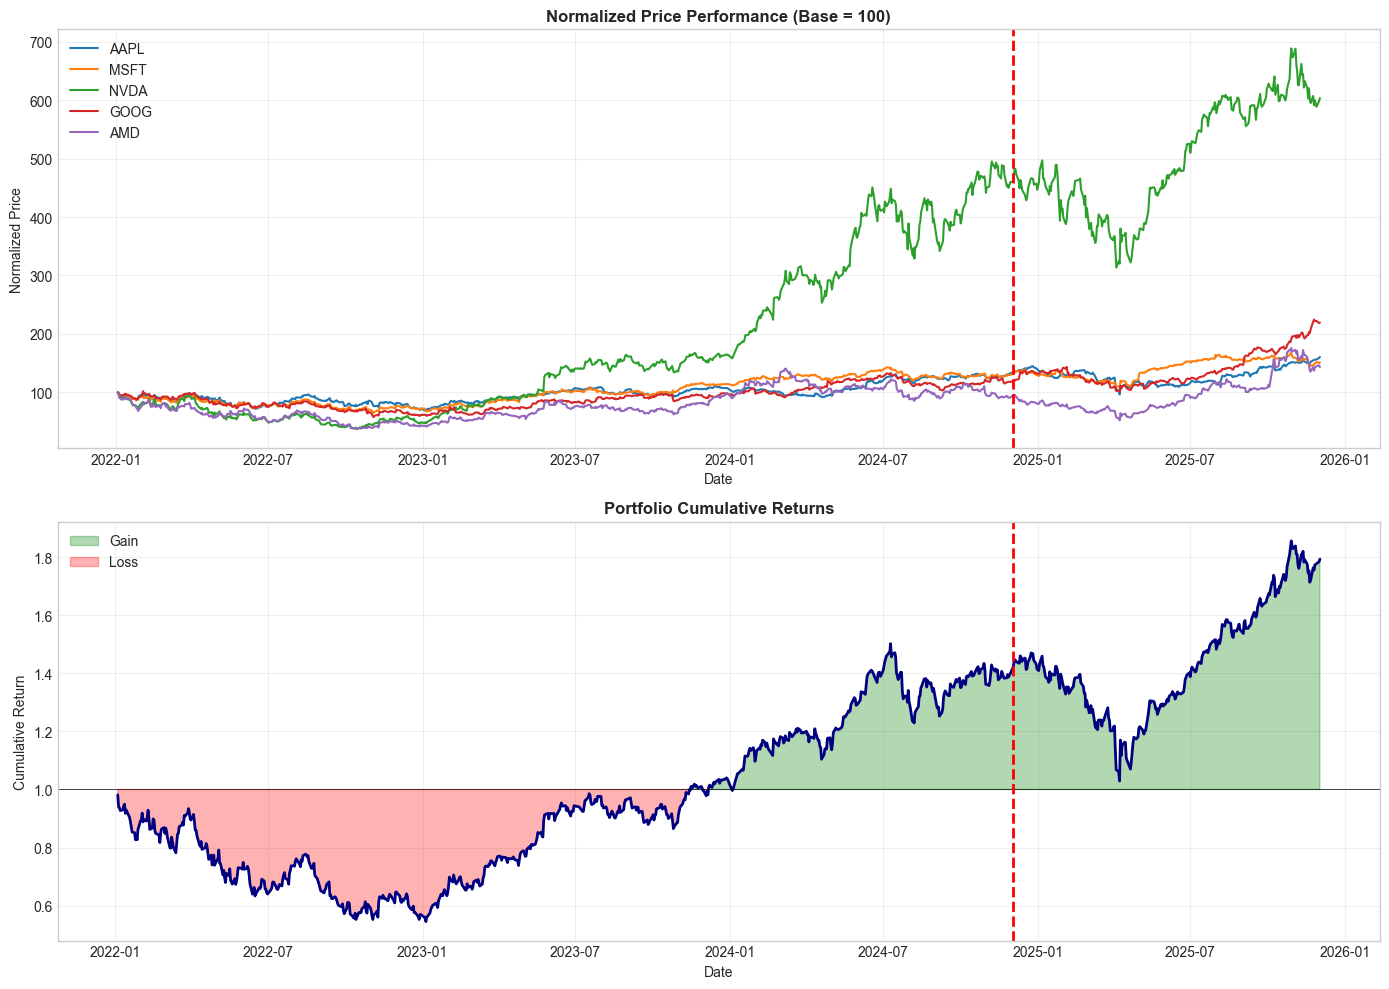

In [12]:
# Price history
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Normalized prices (rebased to 100)
normalized_prices = prices_df / prices_df.iloc[0] * 100

for ticker in TICKERS:
    axes[0].plot(normalized_prices.index, normalized_prices[ticker], label=ticker, linewidth=1.5)

axes[0].set_title('Normalized Price Performance (Base = 100)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Normalized Price')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Add train/test split line
axes[0].axvline(pd.to_datetime(TEST_START), color='red', linestyle='--', linewidth=2, label='Train/Test Split')

# Portfolio cumulative returns
cumulative_returns = (1 + portfolio_returns).cumprod()
axes[1].plot(cumulative_returns.index, cumulative_returns.values, color='navy', linewidth=2)
axes[1].fill_between(cumulative_returns.index, 1, cumulative_returns.values, 
                     where=cumulative_returns.values >= 1, color='green', alpha=0.3, label='Gain')
axes[1].fill_between(cumulative_returns.index, 1, cumulative_returns.values, 
                     where=cumulative_returns.values < 1, color='red', alpha=0.3, label='Loss')
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=0.5)
axes[1].axvline(pd.to_datetime(TEST_START), color='red', linestyle='--', linewidth=2)
axes[1].set_title('Portfolio Cumulative Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_price_performance.png', dpi=300, bbox_inches='tight')
plt.show()

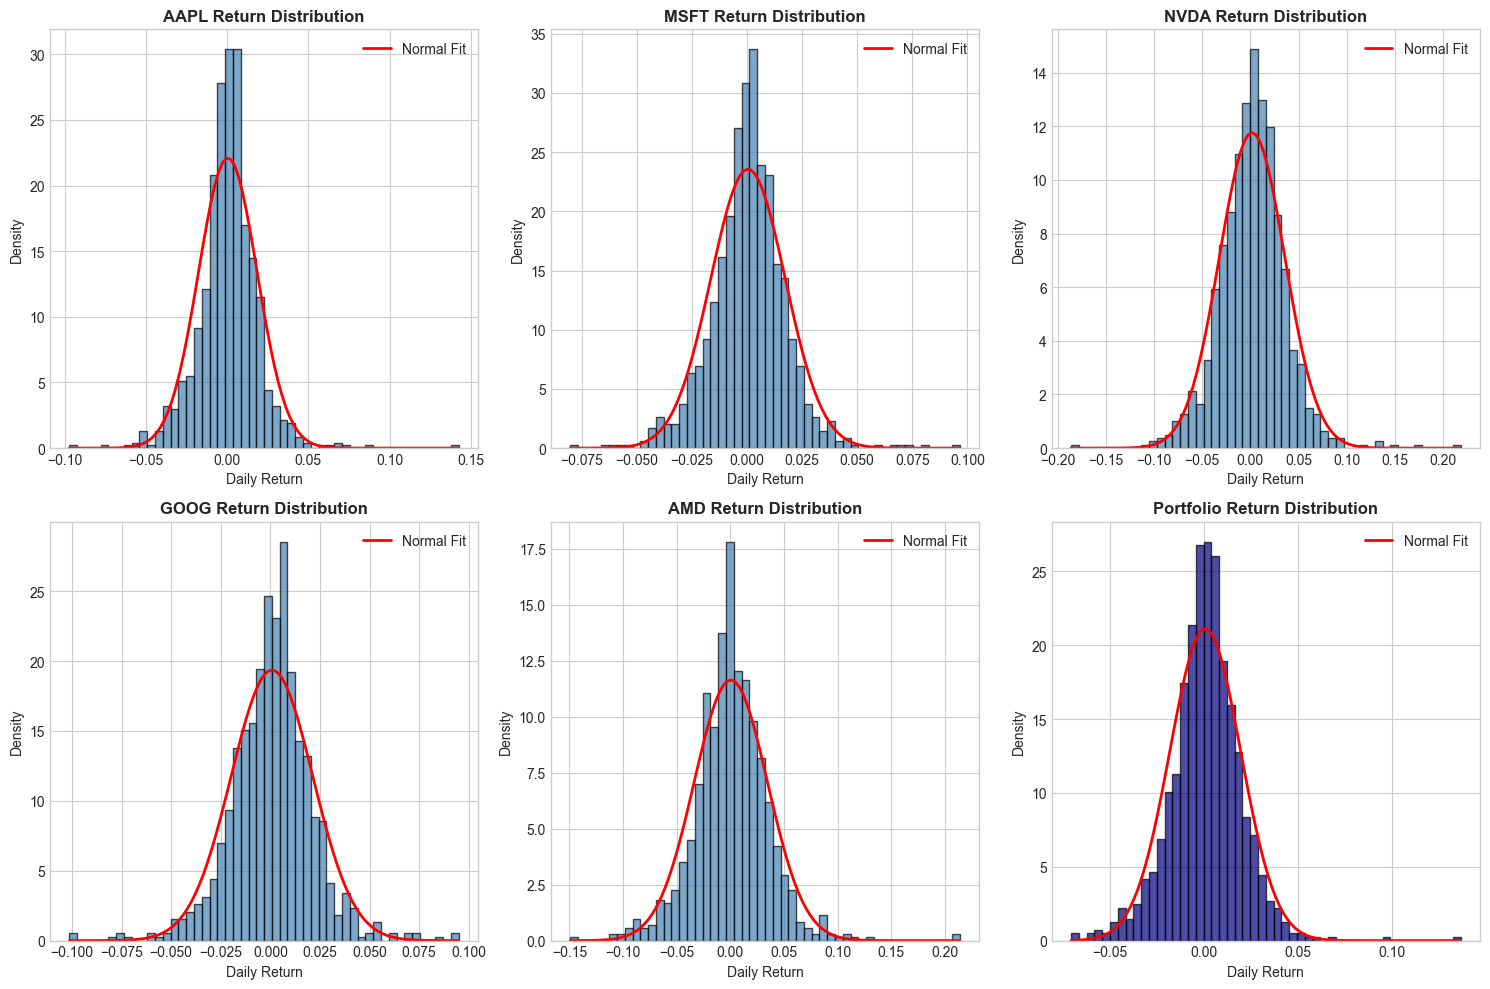

In [13]:
# Return distributions
from scipy.stats import norm

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Individual assets
for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    returns_data = returns_df[ticker]
    
    # Histogram
    ax.hist(returns_data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Normal distribution overlay
    mu, sigma = returns_data.mean(), returns_data.std()
    x = np.linspace(returns_data.min(), returns_data.max(), 100)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')
    
    ax.set_title(f'{ticker} Return Distribution', fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend()

# Portfolio
ax = axes[5]
ax.hist(portfolio_returns, bins=50, density=True, alpha=0.7, color='navy', edgecolor='black')
mu, sigma = portfolio_returns.mean(), portfolio_returns.std()
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')
ax.set_title('Portfolio Return Distribution', fontweight='bold')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_return_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

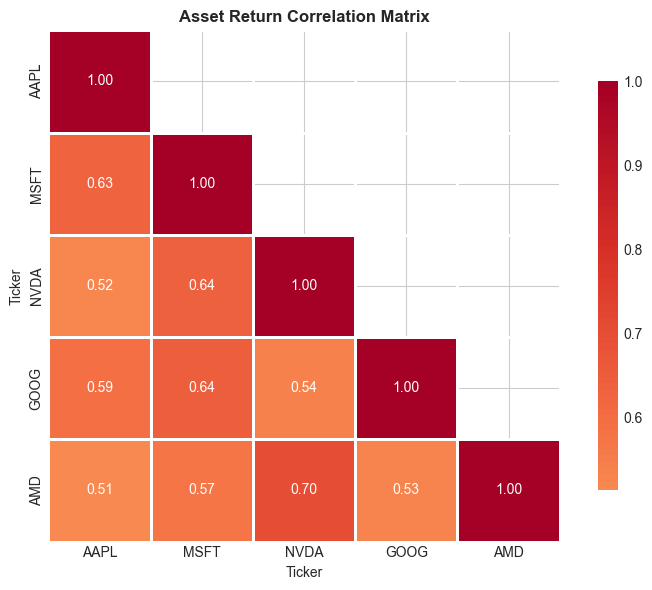

Average pairwise correlation: 0.59


In [14]:
# Correlation matrix
correlation_matrix = returns_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8},
            mask=mask, ax=ax)

ax.set_title('Asset Return Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average pairwise correlation: {correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].mean():.2f}")

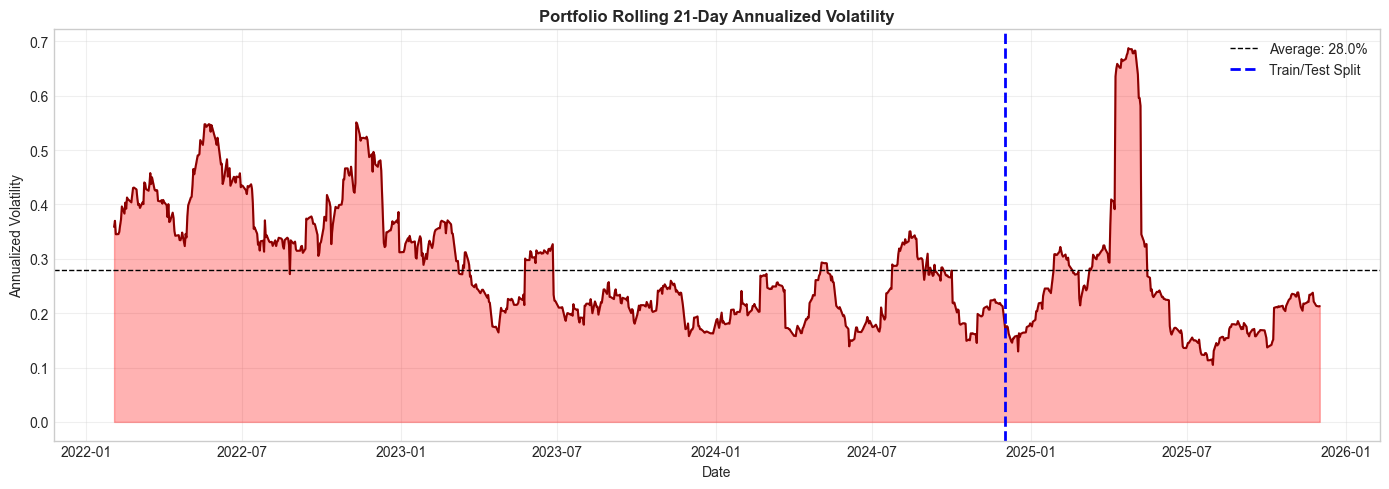

In [15]:
# Rolling volatility
rolling_vol = portfolio_returns.rolling(window=21).std() * np.sqrt(252)  # 21-day rolling annualized vol

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_vol.index, rolling_vol.values, color='darkred', linewidth=1.5)
ax.axhline(y=rolling_vol.mean(), color='black', linestyle='--', linewidth=1, label=f'Average: {rolling_vol.mean():.1%}')
ax.fill_between(rolling_vol.index, 0, rolling_vol.values, alpha=0.3, color='red')

ax.axvline(pd.to_datetime(TEST_START), color='blue', linestyle='--', linewidth=2, label='Train/Test Split')

ax.set_title('Portfolio Rolling 21-Day Annualized Volatility', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_rolling_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.7 Train/Test Split

We split the data into:
- **Training Period**: Used to estimate VaR model parameters
- **Testing Period**: Used for out-of-sample backtesting (approximately 250 trading days)

In [16]:
# Split data
train_returns = portfolio_returns[TRAIN_START:TRAIN_END]
test_returns = portfolio_returns[TEST_START:TEST_END]

train_prices = prices_df[TRAIN_START:TRAIN_END]
test_prices = prices_df[TEST_START:TEST_END]

train_asset_returns = returns_df[TRAIN_START:TRAIN_END]
test_asset_returns = returns_df[TEST_START:TEST_END]

display(Markdown(f"""
### Data Split Summary

| Period | Start | End | Trading Days |
|--------|-------|-----|-------------|
| Training | {TRAIN_START} | {TRAIN_END} | {len(train_returns)} |
| Testing | {TEST_START} | {TEST_END} | {len(test_returns)} |
| Total | {START_DATE} | {END_DATE} | {len(portfolio_returns)} |

**Note:** The testing period of ~250 trading days aligns with Basel III backtesting requirements.
"""))


### Data Split Summary

| Period | Start | End | Trading Days |
|--------|-------|-----|-------------|
| Training | 2022-01-01 | 2024-11-29 | 731 |
| Testing | 2024-12-02 | 2025-11-28 | 249 |
| Total | 2022-01-01 | 2025-12-03 | 982 |

**Note:** The testing period of ~250 trading days aligns with Basel III backtesting requirements.


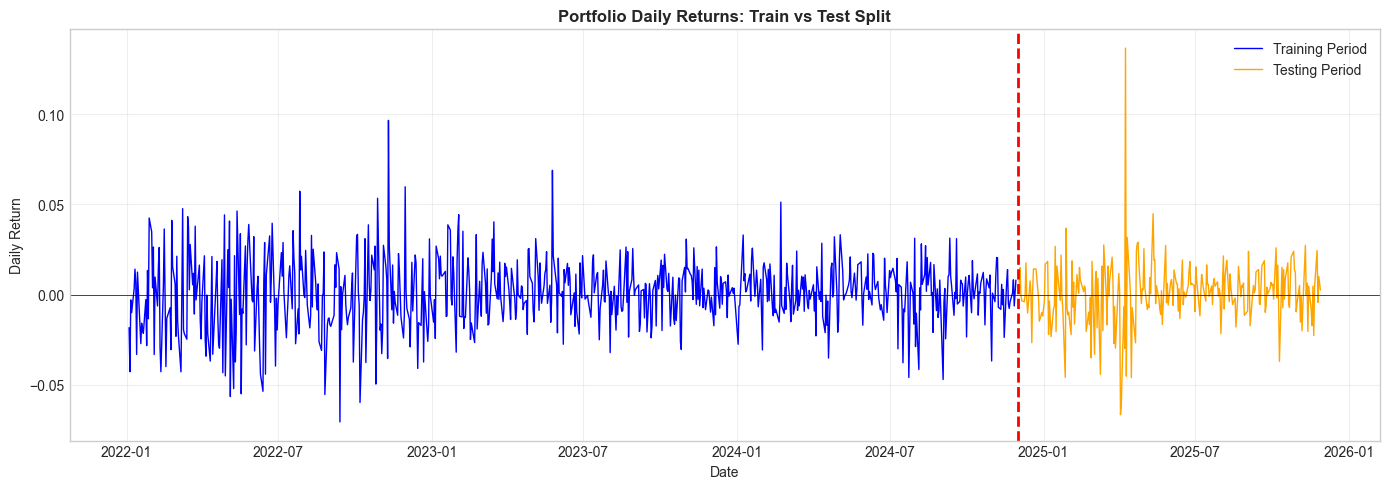

In [17]:
# Visualize train/test split
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_returns.index, train_returns.values, color='blue', linewidth=1, label='Training Period')
ax.plot(test_returns.index, test_returns.values, color='orange', linewidth=1, label='Testing Period')

ax.axvline(pd.to_datetime(TEST_START), color='red', linestyle='--', linewidth=2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

ax.set_title('Portfolio Daily Returns: Train vs Test Split', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.8 Save Prepared Data

Save the prepared datasets for use in subsequent notebooks.

In [18]:
# Save to CSV for later use
prices_df.to_csv('../outputs/prices.csv')
returns_df.to_csv('../outputs/asset_returns.csv')
portfolio_returns.to_frame('portfolio_return').to_csv('../outputs/portfolio_returns.csv')

print("Data saved successfully!")
print("  - outputs/prices.csv")
print("  - outputs/asset_returns.csv")
print("  - outputs/portfolio_returns.csv")

Data saved successfully!
  - outputs/prices.csv
  - outputs/asset_returns.csv
  - outputs/portfolio_returns.csv


---

## Summary

In this notebook, we:

1. **Loaded portfolio configuration** - 5 tech stocks with specified weights
2. **Downloaded historical data** - ~3 years of daily prices from Yahoo Finance
3. **Calculated log returns** - For both individual assets and the portfolio
4. **Analyzed return characteristics** - Observed negative skewness and fat tails
5. **Examined correlations** - High correlation among tech stocks (limited diversification)
6. **Split data** - Training (estimation) and testing (backtesting) periods

**Key Findings:**
- Portfolio exhibits significant volatility clustering
- Returns show fat tails (excess kurtosis) indicating tail risk
- High correlation among assets suggests concentrated sector risk

**Next Steps:**
In Notebook 02, we will implement and compare three VaR methodologies:
- Parametric (Variance-Covariance)
- Historical Simulation
- Monte Carlo Simulation